In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,ConfusionMatrixDisplay)

# Load Dataset

In [8]:
iris = load_iris()

X = iris.data
y = iris.target

# Explore the Dataset

## 1. Basic Information

In [17]:

print("\nNumber of Samples:", len(X))

print("Number of Features:", X.shape[1])

print("Number of Classes:", len(iris.target_names))


Number of Samples: 150
Number of Features: 4
Number of Classes: 3


## 2. Feature Names

In [18]:
print("Feature Names:")
for feature in iris.feature_names:
    print(feature)

Feature Names:
sepal length (cm)
sepal width (cm)
petal length (cm)
petal width (cm)


## 3. Target Classes

In [19]:
print("Target Classes:")

for i, name in enumerate(iris.target_names):
    print(f"{i} : {name}")

Target Classes:
0 : setosa
1 : versicolor
2 : virginica


## 4. Create a DataFrame

In [20]:
df = pd.DataFrame(X, columns=iris.feature_names)

df["Species"] = y

df["Species"] = df["Species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [21]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [22]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(150, 5)


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [24]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [25]:
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


In [26]:
print("Duplicate Rows:")

print(df.duplicated().sum())

Duplicate Rows:
1


In [27]:
print(df["Species"].value_counts())

Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


In [28]:
print(df["Species"].unique())

['Setosa' 'Versicolor' 'Virginica']


In [29]:
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Species               object
dtype: object


In [30]:
print(df.drop("Species", axis=1).corr())

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


## 4. Visual Exploration

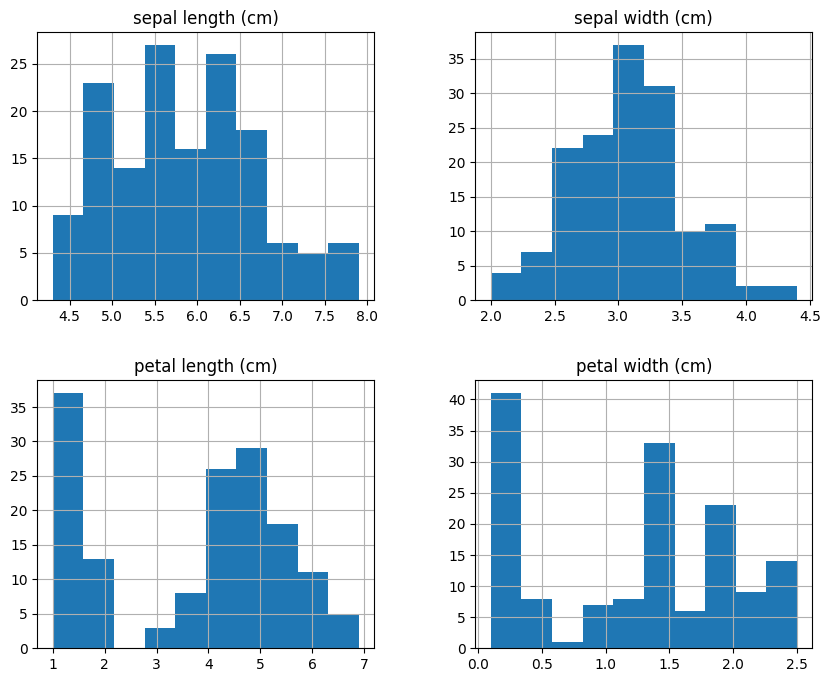

In [31]:
df.hist(figsize=(10,8))

plt.show()

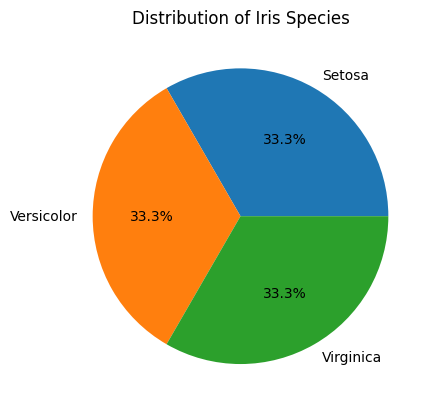

In [32]:
df["Species"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel=""
)

plt.title("Distribution of Iris Species")

plt.show()

# Split the Dataset

The dataset is divided into two parts:

- **Training Set:** Used to train the machine learning model.
- **Testing Set:** Used to evaluate the model on unseen data.

In this notebook, we use:

- **80%** of the data for training.
- **20%** of the data for testing.

Using separate training and testing sets helps measure how well the model generalizes to new data.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape :", X_test.shape)
print("Training Labels Shape  :", y_train.shape)
print("Testing Labels Shape   :", y_test.shape)

Training Features Shape: (120, 4)
Testing Features Shape : (30, 4)
Training Labels Shape  : (120,)
Testing Labels Shape   : (30,)


# Train the Logistic Regression Model

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# Make Predictions

In [35]:
y_pred = model.predict(X_test)

print("Actual Labels:")
print(y_test)

print("\nPredicted Labels:")
print(y_pred)

Actual Labels:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Predicted Labels:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# Accuracy


In [37]:

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


# Precision

In [38]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

Precision: 1.0


# Recall

In [39]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall:", recall)

Recall: 1.0


# F1-Score

In [40]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1-Score:", f1)

F1-Score: 1.0


# Confusion Matrix

In [47]:
from sklearn.metrics import confusion_matrix

confusionMat = confusion_matrix(y_test, y_pred)

print(confusionMat)
# The diagonal values (10, 9, and 11) represent correct predictions, while all off-diagonal values are 0, meaning no sample was misclassified.

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# Graphical Representation of Confusion Matrix

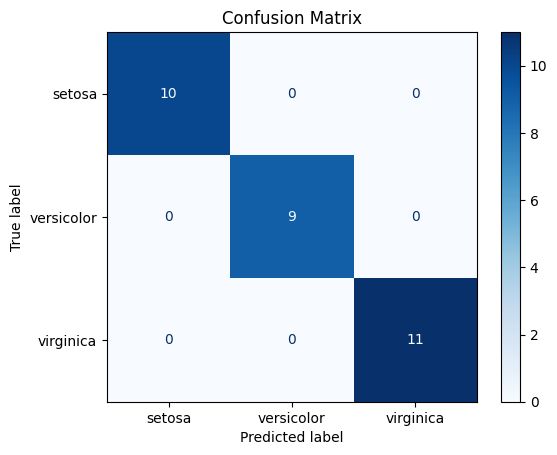

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# Decision Tree Classifier

In [50]:
from sklearn.tree import DecisionTreeClassifier

decision_model = DecisionTreeClassifier(random_state=42)

decision_model.fit(X_train, y_train)

decision_pred = decision_model.predict(X_test)

In [52]:
decisionTree_accuracy = accuracy_score(y_test, decision_pred)
decisionTree_precision = precision_score(y_test, decision_pred, average="weighted")
decisionTree_recall = recall_score(y_test, decision_pred, average="weighted")
decisionTree_f1 = f1_score(y_test, decision_pred, average="weighted")


print("Accuracy :", decisionTree_accuracy)
print("Precision:", decisionTree_precision)
print("Recall   :", decisionTree_recall)
print("F1-Score :", decisionTree_f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [55]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [accuracy, precision, recall, f1],
    "Decision Tree": [decisionTree_accuracy, decisionTree_precision,decisionTree_recall, decisionTree_f1]
})

comparison

,Metric,Logistic Regression,Decision Tree
0,Accuracy,1.0,1.0
1,Precision,1.0,1.0
2,Recall,1.0,1.0
3,F1-Score,1.0,1.0
